# Decision Trees and Random Forests

Decision Trees are a non-parametric supervised learning method used for classification and regression. The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features.

Decision Trees learn from data with a set of if-then-else decision rules. The deeper the tree, the more complex the decision rules and the fitter the model.

More information in [Decision Trees](https://scikit-learn.org/stable/modules/tree.html).

In [1]:
# Import the necessary modules and libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

import warnings
warnings.simplefilter('ignore')

%matplotlib inline
%config InlineBackend.figure_format = "retina"

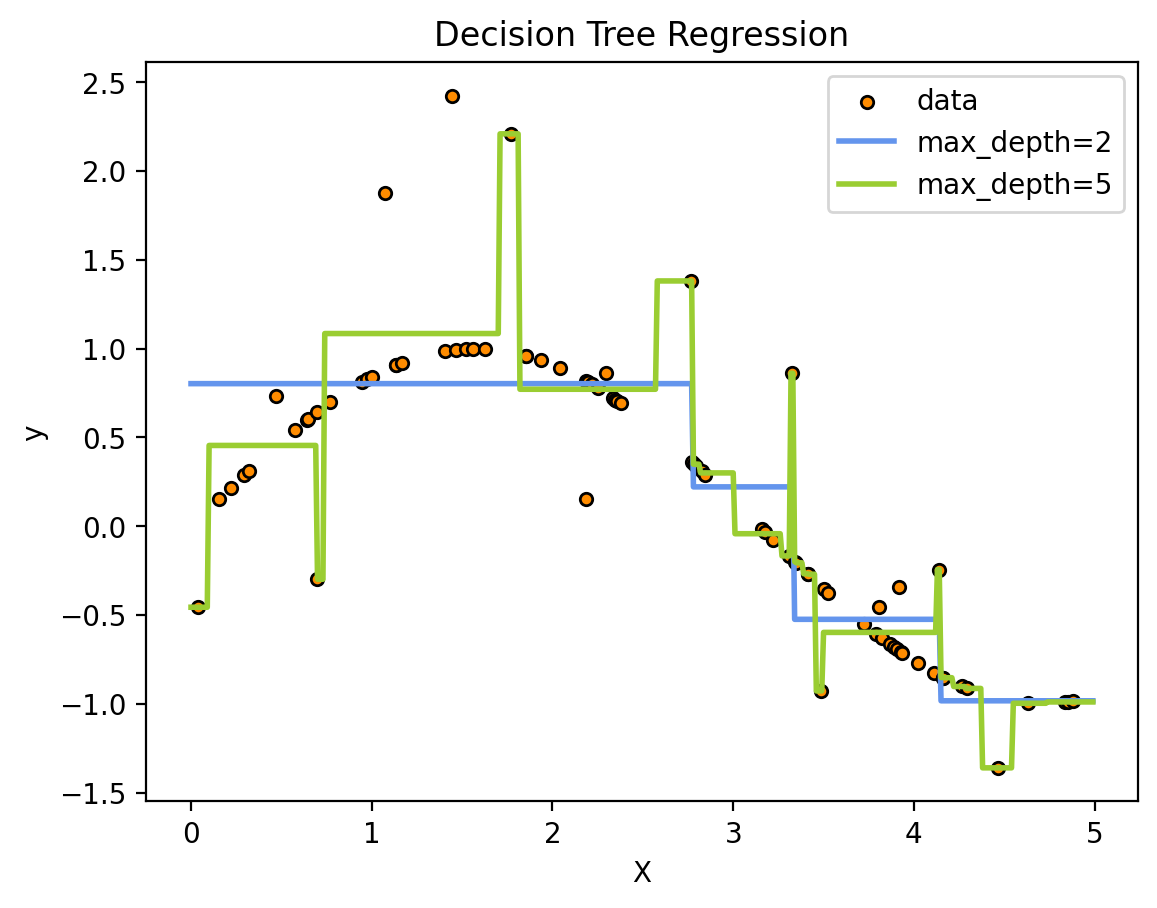

In [ ]:
# Create a random dataset
rng = np.random.default_rng(42)
X = np.sort(5 * rng.random(80), axis=0).reshape(-1, 1)
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - rng.random(16))

# Fit and predict regression model with max_depth=2
regr_1 = DecisionTreeRegressor(max_depth=2)
regr_1.fit(X, y)
y_1 = regr_1.predict(X_test)

# Fit regression model with max_depth=5
regr_2 = DecisionTreeRegressor(max_depth=5)
regr_2.fit(X, y)
y_2 = regr_2.predict(X_test)

# Plot the results
plt.figure()
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_test, y_1, color="cornflowerblue", label="max_depth=2", linewidth=2)
plt.plot(X_test, y_2, color="yellowgreen", label="max_depth=5", linewidth=2)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

In [3]:
3 * (0.5 - rng.random(16))

array([ 0.41456217,  1.23705024,  1.14598229, -1.38569299, -1.22574207,
       -0.5991214 ,  0.70239012, -1.40752913, -0.83625271, -0.65067057,
        0.15191549,  0.68327531,  1.21082711, -1.20780719,  0.13267113,
        0.89290991])

## Decision Trees

This data set consists of 3 different types of irises' (Setosa, Versicolour, and Virginica) petal and sepal length, stored in a 150x4 array. The rows being the samples and the columns being: Sepal Length, Sepal Width, Petal Length and Petal Width.

In [4]:
from sklearn.datasets import load_iris
from sklearn.tree import plot_tree, export_graphviz

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.DataFrame(iris.target, columns=["species"])
clf = DecisionTreeClassifier(max_leaf_nodes=3, random_state=42)
clf.fit(X, y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

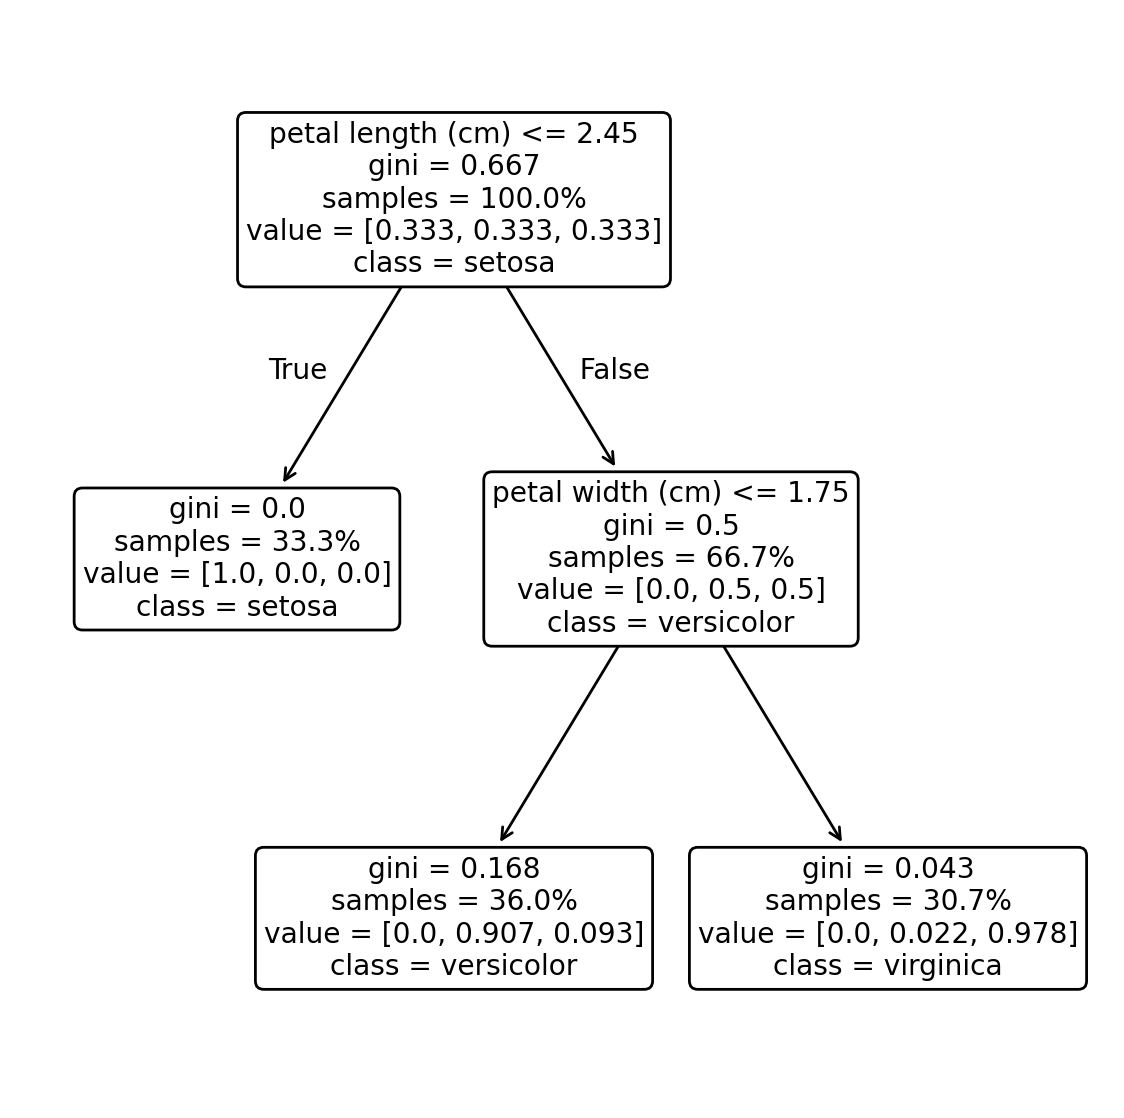

In [5]:
plt.figure(figsize=(7, 7))
plot_tree(clf, proportion=True, rounded=True,
          feature_names=iris.feature_names, class_names=iris.target_names)
plt.show()

### How to Read the Decision Tree Plot

**The Iris Data Intuition:**
Imagine classifying 3 types of iris flowers (Setosa, Versicolor, Virginica) based on 4 measurements: Sepal Length, Sepal Width, Petal Length, and Petal Width. We have 150 flowers total (50 of each type).

**Reading the Tree - Step by Step:**

Each box in the tree shows:
- **Top line**: The decision rule (e.g., "petal length ≤ 2.45?")
- **Middle section**: How many samples reached this node and their class distribution
- **Color intensity**: Darker = more certain (one class dominates)

**To classify a new flower:**
1. Start at the root (top node)
2. Answer the question: Is petal length ≤ 2.45?
3. Go LEFT if YES, RIGHT if NO
4. Repeat at the next node until you reach a leaf (final node)
5. The predicted class is the one with most samples in that leaf

**Example:**
A new flower has: petal length = 3.0, petal width = 0.5
- "Is petal length ≤ 2.45?" → NO (go right)
- "Is petal width ≤ 1.75?" → YES (go left)
- **Prediction: Versicolor** ✓

For example, in the above tree built on the iris dataset, the root node has value = [0.33, 0.33, 0.33] indicating there are 33% of class 0 samples, 33% of class 1 samples, and 33% of class 2 samples at the root node.

One can convert this to the absolute number of samples by multiplying by the number of samples reaching the root node, which is `clf.tree_.weighted_n_node_samples[0]`. Then the root node has value = [50, 50, 50].

Traversing the tree, the samples are split and as a result, the value array reaching each node changes. The left child of the root node has value = [1., 0, 0] because all 50 samples in the left child node are from class 0.

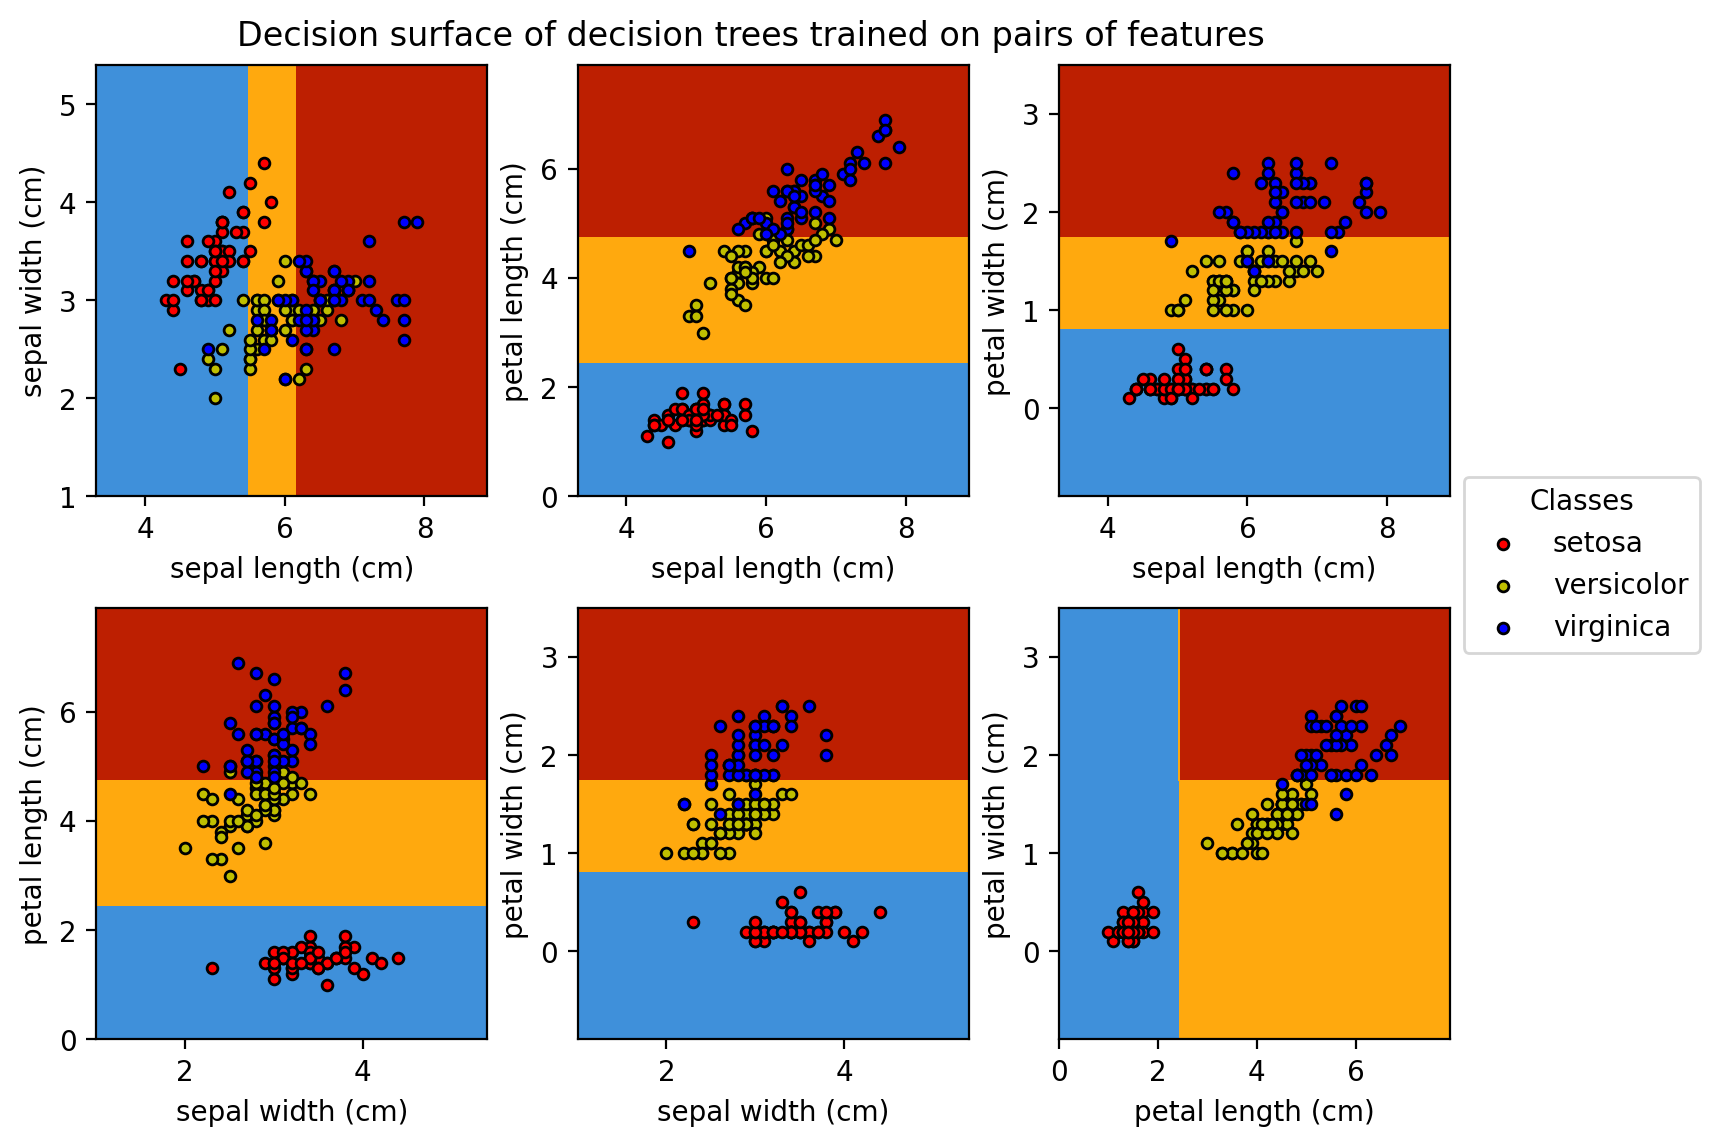

In [6]:
from sklearn.inspection import DecisionBoundaryDisplay

# Parameters
n_classes = 3
plot_colors = "ryb"
plot_step = 0.02
plt.figure(figsize=(8, 6))

for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]):
    # We only take the two corresponding features
    X = iris.data[:, pair]
    y = iris.target

    # Train
    clf = DecisionTreeClassifier(max_leaf_nodes=3, random_state=42).fit(X, y)

    # Plot the decision boundary
    ax = plt.subplot(2, 3, pairidx + 1)
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
    DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
        ax=ax,
        xlabel=iris.feature_names[pair[0]],
        ylabel=iris.feature_names[pair[1]],
    )

    # Plot the training points
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i)
        plt.scatter(
            X[idx, 0],
            X[idx, 1],
            c=color,
            label=iris.target_names[i],
            edgecolor="black",
            s=15,
        )

plt.suptitle("Decision surface of decision trees trained on pairs of features")
plt.legend(loc="center left", bbox_to_anchor=(1, 1.1), title="Classes")
_ = plt.axis("tight")

Plot of decision surface of a decision tree trained on pairs of features of the iris dataset.

For each pair of iris features, the decision tree learns decision boundaries made of combinations of simple thresholding rules inferred from the training samples.

### Using Graphviz

Note: you may need to restart the kernel to use updated packages.


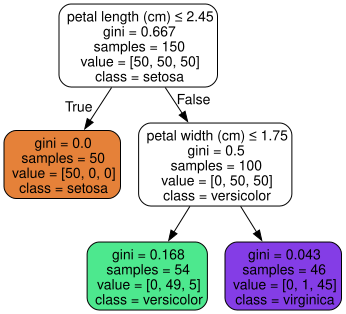

In [7]:
%pip install graphviz

import graphviz

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.DataFrame(iris.target, columns=["species"])
clf = DecisionTreeClassifier(max_leaf_nodes=3, random_state=42)
clf.fit(X, y)

dot_data = export_graphviz(clf, out_file=None, feature_names=iris.feature_names,
                           class_names=iris.target_names, filled=True, rounded=True,
                           special_characters=True)
graph = graphviz.Source(dot_data)
graph

### Tips on practical use:

1.	Overfitting and Dimensionality Reduction: Decision trees tend to overfit with many features. Dimensionality reduction (e.g., PCA or feature selection) can help by focusing on key discriminative features.

2.	Tree Structure and Visualization: Visualizing the tree helps understand its predictions. Start with `max_depth=3` to assess fit, then adjust accordingly.

3.	Sample Size Control: Control tree growth with max_depth, as the required samples double with each level. Use `min_samples_leaf=5` to ensure each decision is based on sufficient samples and avoid overfitting.

4.	Class Imbalance: Balance classes before training to avoid bias. Normalizing sample weights helps prevent trees from favoring dominant classes.

5.	Sparse Matrix Optimization: Use sparse matrices (e.g., csc_matrix for fitting and csr_matrix for predicting) when input data contains many zero values, as it improves training speed significantly.

## From One Tree to Many: Ensemble Methods

A single tree has one big weakness: it is **unstable**. Change a few observations and the first split can move, and then every split below it changes too. In bias–variance language:

- A deep tree has **low bias**: it can follow almost any pattern in the data.
- It also has **high variance**: its predictions change a lot from one sample to the next.

**Comparison with OLS.** A regression tree is really an OLS regression. Once the tree has picked its leaves (regions) $R_1, \dots, R_M$, the prediction is

$$\hat f(x) = \sum_{m=1}^{M} \hat\beta_m \, \mathbf{1}\{x \in R_m\}, \qquad \hat\beta_m = \text{average of } y \text{ in leaf } m,$$

which is exactly OLS of $y$ on a set of leaf dummies. The difference from the regressions you already know is that **the data picks the dummies**. That step is what makes a tree flexible, and it is also what makes a tree noisy.

| | OLS | Regression tree |
|---|---|---|
| Regressors | chosen by the researcher ($x_1, x_2, x_1^2, x_1 x_2, \dots$) | leaf dummies $\mathbf{1}\{x \in R_m\}$, chosen by the algorithm **using $y$** |
| Prediction | $\hat\beta' x$ | average of $y$ in the leaf where $x$ lands |
| Functional form | you must specify it (logs, polynomials, interactions) | found automatically (a step function) |
| Main risk | misspecification → **bias** | overfitting → **variance** |
| Stability | stable | small changes in the data → a very different tree |

**Ensemble methods** grow **many trees and combine them**. The two main families fix *different* problems:

- **Bagging / Random Forests** grow many **deep** trees *in parallel* and **average** them. This reduces **variance**.
- **Boosting** grows many **small** trees *one after another*, each correcting the previous ones. This reduces **bias**.

First, let's see the instability directly.

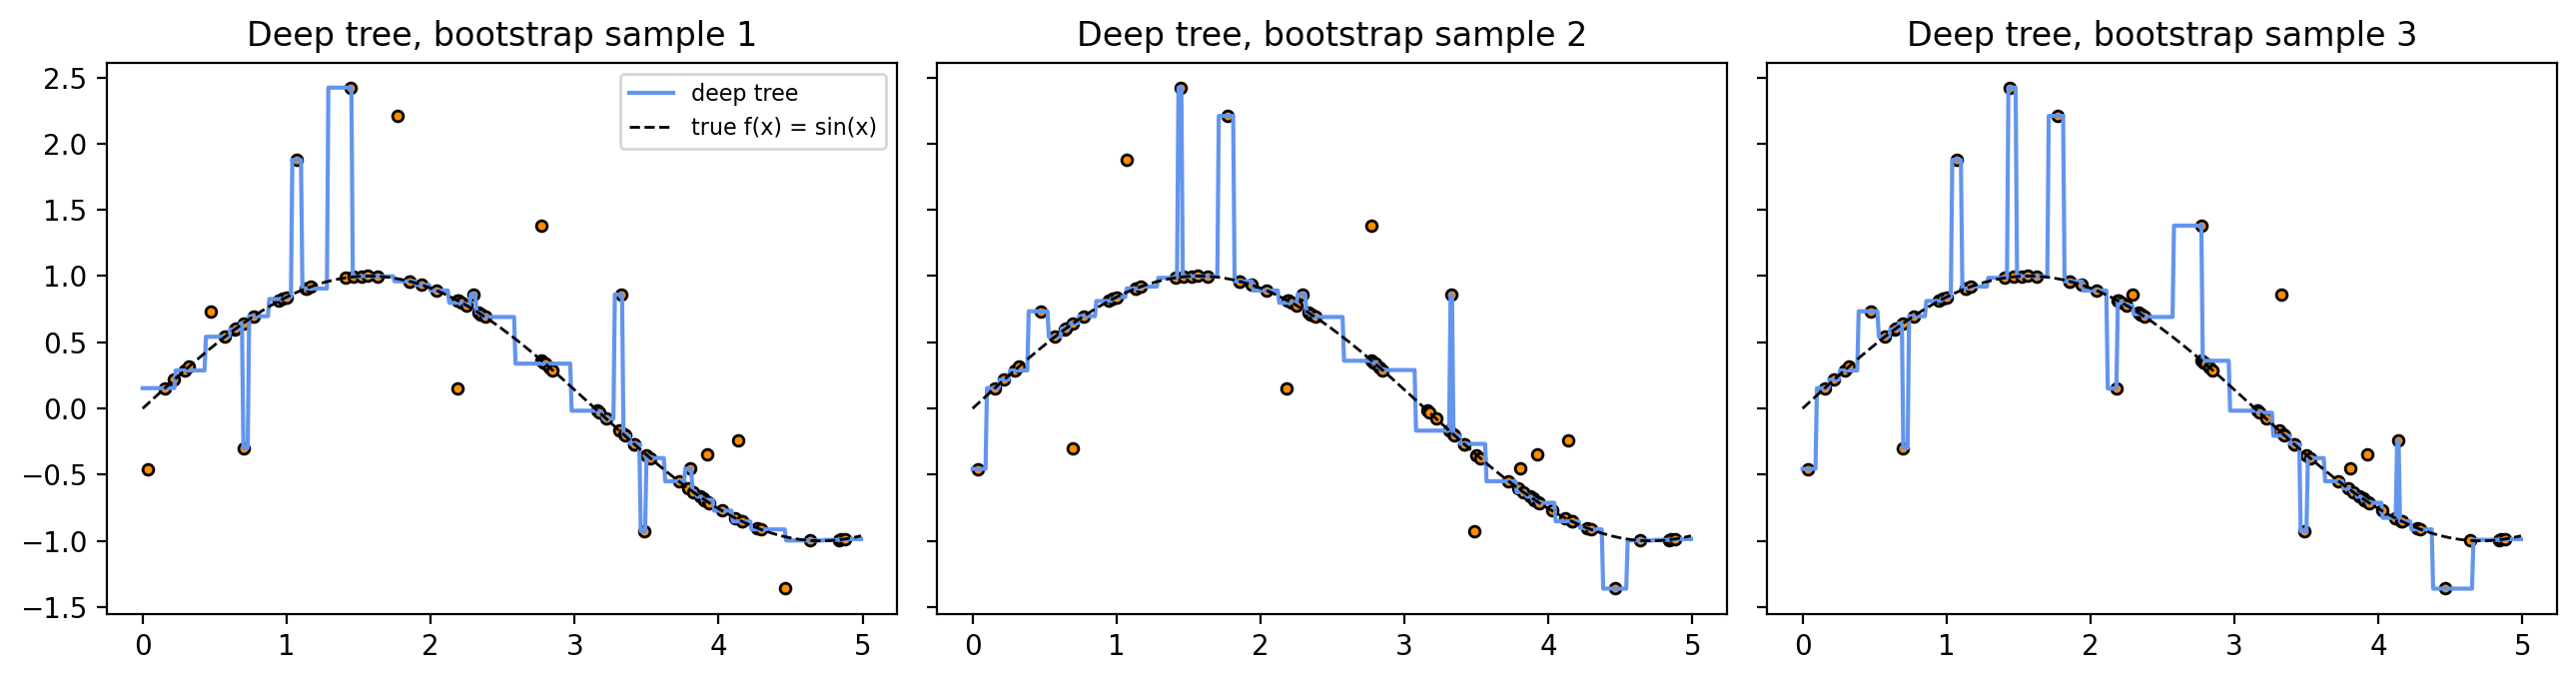

In [8]:
# Same sine data as at the top of the notebook (new names, so X and y used below are not overwritten)
rng_e = np.random.default_rng(42)
X_sin = np.sort(5 * rng_e.random(80), axis=0).reshape(-1, 1)
y_sin = np.sin(X_sin).ravel()
y_sin[::5] += 3 * (0.5 - rng_e.random(16))
X_grid = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]

# Fit a deep (unpruned) tree on 3 bootstrap samples: resample the 80 rows WITH replacement
fig, ax = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for k in range(3):
    idx = rng_e.integers(0, len(y_sin), len(y_sin))
    tree_k = DecisionTreeRegressor(random_state=0).fit(X_sin[idx], y_sin[idx])
    ax[k].scatter(X_sin, y_sin, s=15, c="darkorange", edgecolor="black")
    ax[k].plot(X_grid, tree_k.predict(X_grid), color="cornflowerblue", label="deep tree")
    ax[k].plot(X_grid, np.sin(X_grid), "k--", lw=1, label="true f(x) = sin(x)")
    ax[k].set_title(f"Deep tree, bootstrap sample {k + 1}")
ax[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

Same data-generating process, slightly different samples, and the three fitted curves disagree a lot, especially near the outliers. That disagreement is the **variance** of the tree. The rest of this section is about how to reduce it.

## Bagging (**B**ootstrap **Agg**regat**ing**)

**Intuition.** If one noisy estimate is bad, average many of them. This is the same logic as the sample mean: one observation has variance $\sigma^2$, and the mean of $n$ independent observations has variance $\sigma^2/n$. We only have one dataset, so we use the **bootstrap** to create many "new" ones.

**How to compute it:**

1. Draw a **bootstrap sample**: $n$ rows drawn *with replacement* from the training data.
2. Grow a **deep, unpruned** tree on that sample.
3. Repeat $B$ times (e.g. $B = 100$ to $500$).
4. Combine: **average** the $B$ predictions (regression) or take a **majority vote** (classification).

$$\hat f^{\text{bag}}(x) = \frac{1}{B}\sum_{b=1}^{B}\hat f^{\,b}(x)$$

**What this means for the data.**

- A bootstrap sample repeats some rows 2 or 3 times and leaves others out. On average each tree sees only **about 63%** of the distinct observations.
- The **roughly 37%** that a tree did not see are its **out-of-bag (OOB)** observations, which work as a free test set. Predict each observation using only the trees that never saw it, and you get an honest error estimate without cross-validation.

**Properties of bagging:**

| Property | What happens |
|---|---|
| Bias | About the same as one deep tree (stays low) |
| Variance | Falls a lot. This is the whole point |
| Number of trees $B$ | More trees never hurt. $B$ is a *computing budget*, not a tuning parameter |
| Pruning | Not needed. Trees are grown deep **on purpose**, and averaging removes the noise |
| Interpretability | Lost. You can't draw 500 trees, so use variable importance instead |
| Computation | Trees are independent, so they can be fit in parallel |

**Comparison with OLS.** Suppose you ran the same OLS regression on 500 bootstrap samples and averaged the fitted values. You would get almost exactly the original OLS fit, because OLS is already stable. A tree is unstable, so averaging changes it a lot. **Bagging helps most when the base estimator has high variance.**

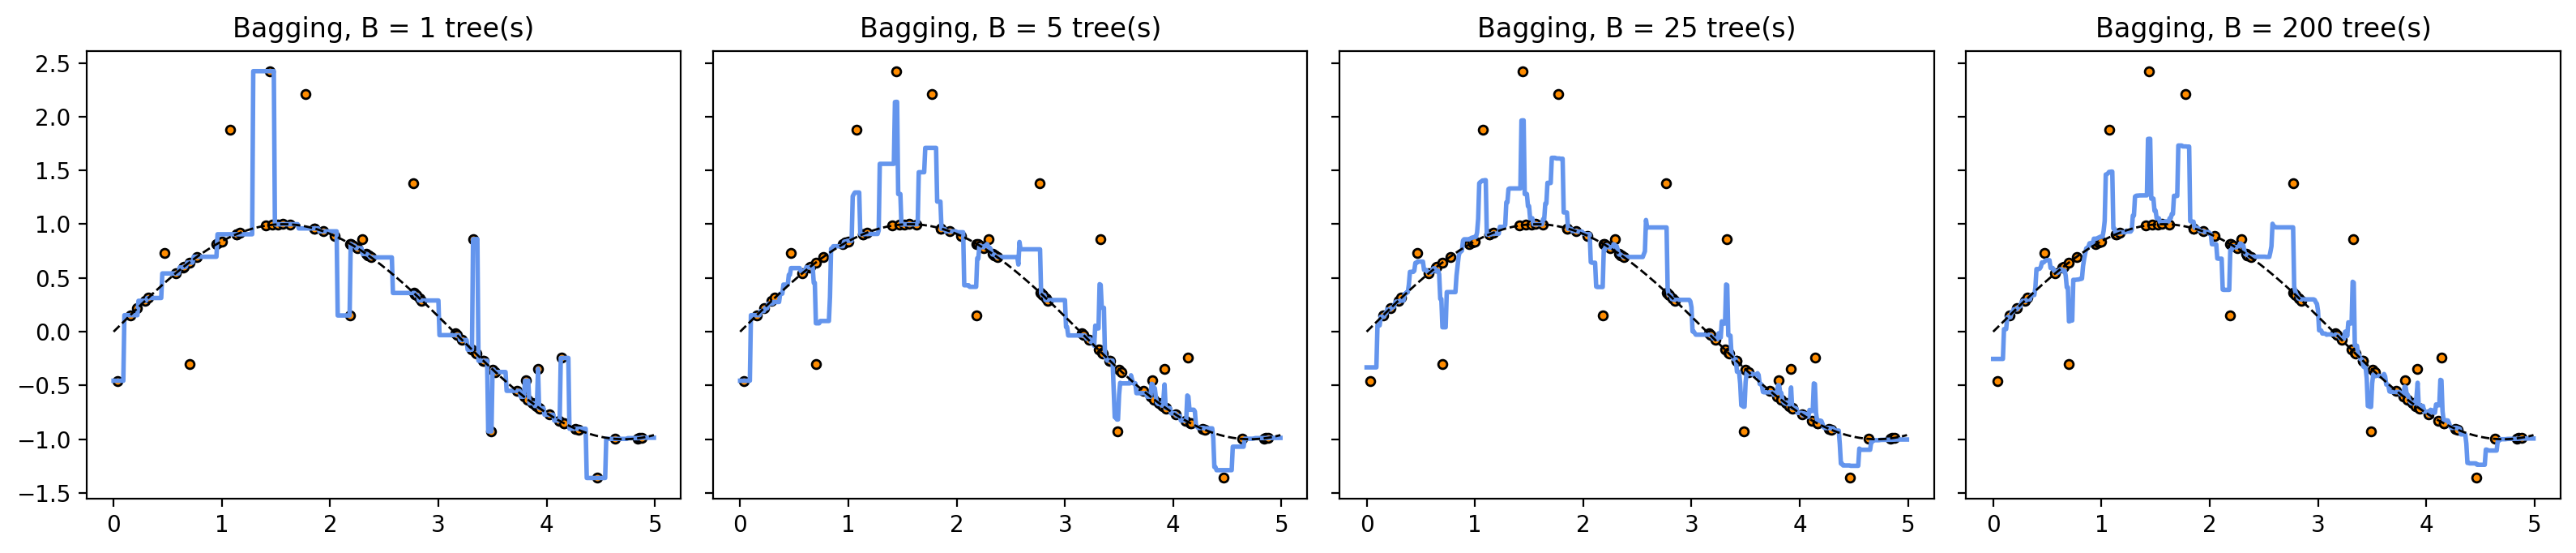

In [9]:
from sklearn.ensemble import BaggingRegressor

fig, ax = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)
for a, B in zip(ax, [1, 5, 25, 200]):
    bag = BaggingRegressor(DecisionTreeRegressor(), n_estimators=B, random_state=0).fit(X_sin, y_sin)
    a.scatter(X_sin, y_sin, s=15, c="darkorange", edgecolor="black")
    a.plot(X_grid, bag.predict(X_grid), color="cornflowerblue", lw=2)
    a.plot(X_grid, np.sin(X_grid), "k--", lw=1)
    a.set_title(f"Bagging, B = {B} tree(s)")
plt.tight_layout()
plt.show()

**How to read the plots.** With $B = 1$ we get the jagged step function of a single deep tree. As $B$ grows, the random jumps that differ from one tree to the next average out, and the curve becomes smoother and closer to $\sin(x)$ in most places. Going from 25 to 200 trees changes little, which shows that extra trees stop helping but don't hurt. Spikes remain around the outliers, because *every* deep tree chases them: averaging removes the part of the error that differs across trees (**variance**), not the part they share (**bias**).

Next, we check the "63%" claim and use the out-of-bag observations as a free validation set on the iris data.

In [10]:
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import cross_val_score

# (1) The 63% fact: share of DISTINCT rows that end up in a bootstrap sample
n_rows = 1000
shares = [len(np.unique(rng_e.integers(0, n_rows, n_rows))) / n_rows for _ in range(500)]
print(f"Average share of distinct rows in a bootstrap sample: {np.mean(shares):.3f}"
      f"   (theory: 1 - 1/e = {1 - np.exp(-1):.3f})")

# (2) Out-of-bag accuracy vs 5-fold cross-validation, iris data
X_iris, y_iris = iris.data, iris.target
bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=200,
                            oob_score=True, random_state=0).fit(X_iris, y_iris)
cv_acc = cross_val_score(BaggingClassifier(DecisionTreeClassifier(), n_estimators=200, random_state=0),
                         X_iris, y_iris, cv=5).mean()
print(f"\nOut-of-bag accuracy : {bag_clf.oob_score_:.3f}   <- one fit, comes for free")
print(f"5-fold CV accuracy  : {cv_acc:.3f}   <- five extra fits")

Average share of distinct rows in a bootstrap sample: 0.632   (theory: 1 - 1/e = 0.632)

Out-of-bag accuracy : 0.960   <- one fit, comes for free
5-fold CV accuracy  : 0.967   <- five extra fits


### Why bagging hits a ceiling, and how Random Forests fix it

The bootstrap samples overlap heavily, so the bagged trees **look alike**. If one variable is a strong predictor (for example, *education* in a wage regression), *every* tree splits on it first, and the trees end up very similar. Averaging near-copies of the same tree is like averaging polls that all called the same people: you don't learn much more.

A simple formula makes this precise. Suppose there are $B$ trees, each with variance $\sigma^2$, and any two trees have correlation $\rho$. Then

$$\text{Var}\big(\text{average of } B \text{ trees}\big) \;=\; \underbrace{\rho\,\sigma^2}_{\text{floor: more trees can't remove it}} \;+\; \underbrace{\frac{1-\rho}{B}\,\sigma^2}_{\text{goes to 0 as } B \text{ grows}}$$

- If trees were independent ($\rho = 0$), we would be back to $\sigma^2/B$, the sample-mean case.
- With correlated trees, adding more trees **cannot** push the variance below $\rho\sigma^2$. The only way to lower it is to make the trees **less correlated**.

That is the idea behind a **Random Forest**: at *every split*, a tree may only choose from a **random subset** of `max_features` variables. The dominant variable is sometimes unavailable, so trees are forced to try other variables and end up different from each other.

| | Bagging | Random Forest |
|---|---|---|
| Rows used by each tree | bootstrap sample | bootstrap sample |
| Variables considered at each split | **all** $p$ | random subset of $q < p$ (`max_features`) |
| Correlation between trees $\rho$ | higher | **lower** |
| Accuracy of each single tree | better | a bit worse (the best variable is sometimes unavailable) |
| Variance of the average | higher floor | **lower floor** |
| Tuning | $B$ only (a budget) | $B$ (a budget) and $q$ (choose by CV / OOB) |
| scikit-learn | `BaggingRegressor(DecisionTreeRegressor())` or `RandomForestRegressor(max_features=1.0)` | `RandomForestRegressor(max_features="sqrt")` or `max_features=1/3` |

⚠ **Watch the default.** `RandomForestRegressor()` uses `max_features=1.0` by default, so it is **plain bagging** unless you change it. `RandomForestClassifier()` defaults to `"sqrt"`. **Bagging is simply a random forest with $q = p$.**

Smaller $q$ means less correlated trees (lower variance) but weaker individual trees (more bias). In practice, pick $q$ by cross-validation or OOB error. The gain from tuning it is often modest.

## Random Forests

Ensemble methods combine the predictions of several base estimators built with a given learning algorithm in order to improve over a single estimator.

Random Forests are an ensemble learning method that fits a number of decision tree classifiers on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.

In random forests, each tree in the ensemble is built from a sample drawn with replacement (i.e., a bootstrap sample) from the training set. Furthermore, when splitting each node during the construction of a tree, the best split is found through an exhaustive search of the features values of either all input features or a random subset of size `max_features`. (See the parameter tuning guidelines for more details.)

The purpose of these two sources of randomness is to decrease the variance of the forest estimator. In practice the variance reduction is often significant hence yielding an overall better model.

In [11]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

clf = DecisionTreeClassifier(max_depth=None, min_samples_split=2, random_state=42)
scores = cross_val_score(clf, X, y, cv=5)
print("Decision Tree Accuracy: %0.3f (+/- %0.3f)" % (scores.mean(), scores.std() * 2))

clf = RandomForestClassifier(n_estimators=10, max_depth=None, min_samples_split=2, random_state=42)
scores = cross_val_score(clf, X, y, cv=5)
print("Random Forest Accuracy: %0.3f (+/- %0.3f)" % (scores.mean(), scores.std() * 2))

gb_clf = GradientBoostingClassifier(n_estimators=10, learning_rate=1.0, max_depth=10, random_state=42)
scores = cross_val_score(gb_clf, X, y, cv=5)
print("Gradient Boosting Accuracy: %0.3f (+/- %0.3f)" % (scores.mean(), scores.std() * 2))

Decision Tree Accuracy: 0.953 (+/- 0.068)
Random Forest Accuracy: 0.967 (+/- 0.042)
Gradient Boosting Accuracy: 0.967 (+/- 0.073)


DecisionTree with features [0, 1] has a score of 0.927
RandomForest with 30 estimators with features [0, 1] has a score of 0.913
DecisionTree with features [0, 2] has a score of 0.993
RandomForest with 30 estimators with features [0, 2] has a score of 0.993
DecisionTree with features [2, 3] has a score of 0.993
RandomForest with 30 estimators with features [2, 3] has a score of 0.993


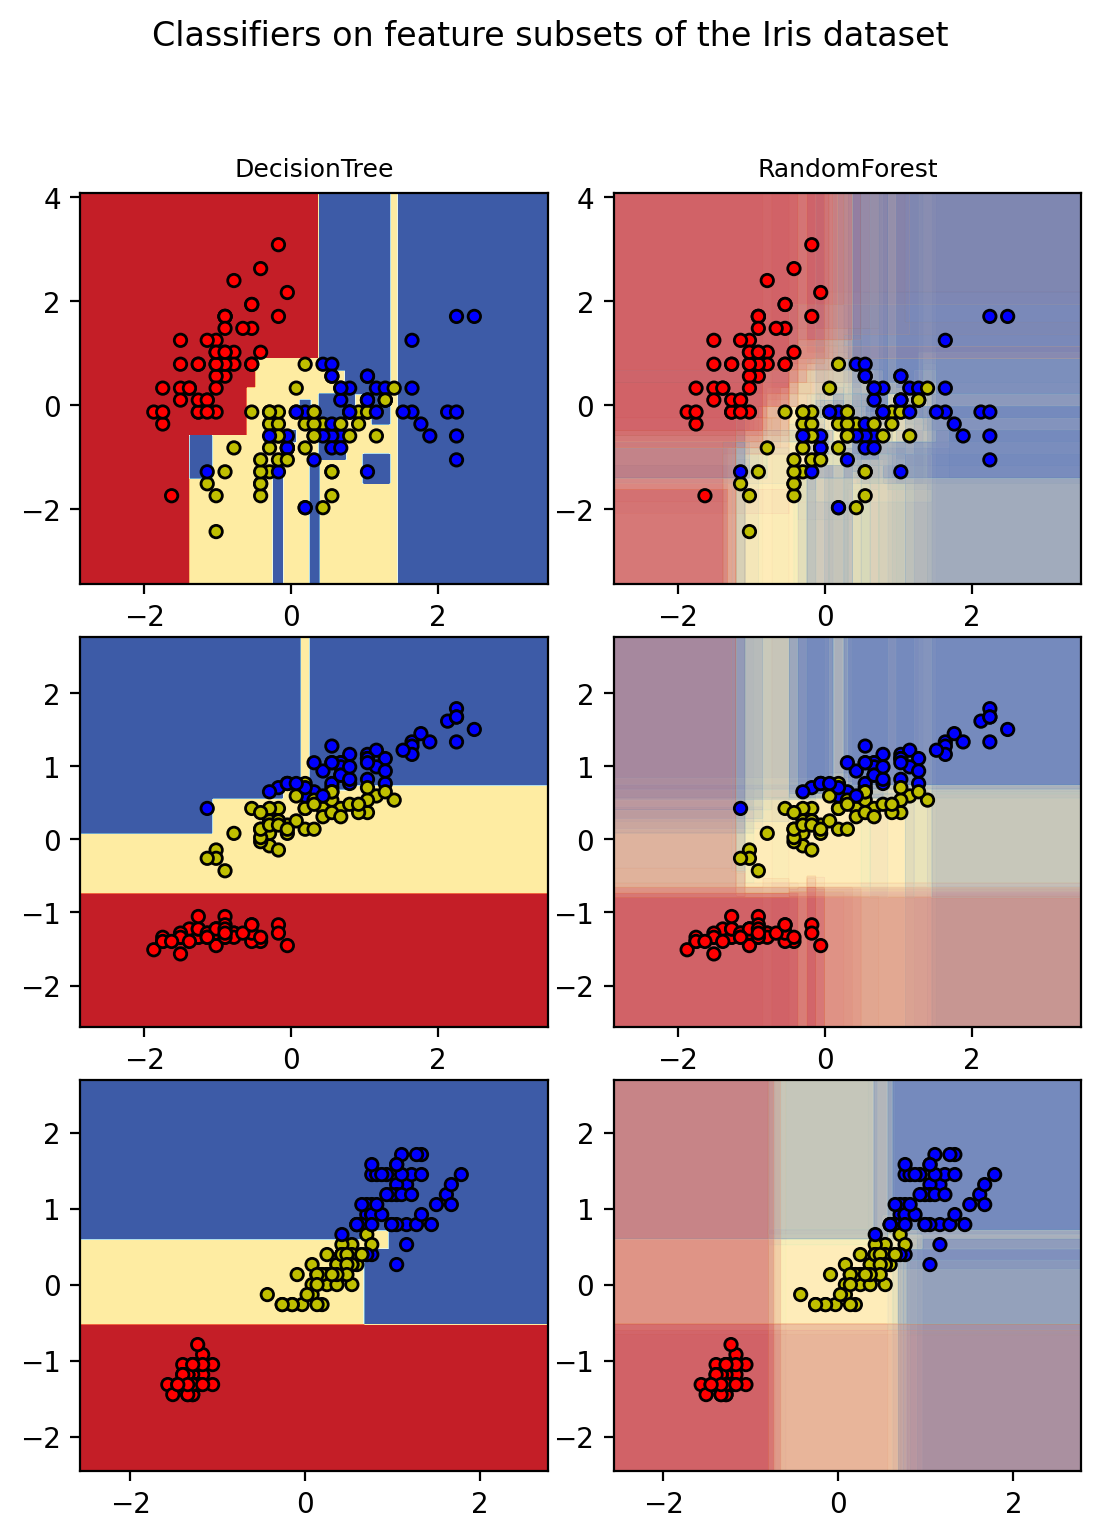

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Parameters
n_classes = 3
n_estimators = 30
cmap = plt.cm.RdYlBu
plot_step = 0.02  # fine step width for decision surface contours
plot_step_coarser = 0.5  # step widths for coarse classifier guesses
RANDOM_SEED = 42  # fix the seed on each iteration
plt.figure(figsize=(6, 8))

# Load data
iris = load_iris()

plot_idx = 1

models = [
    DecisionTreeClassifier(max_depth=None),
    RandomForestClassifier(n_estimators=n_estimators),
]

for pair in ([0, 1], [0, 2], [2, 3]):
    for model in models:
        # We only take the two corresponding features
        X = iris.data[:, pair]
        y = iris.target

        # Shuffle
        idx = np.arange(X.shape[0])
        np.random.seed(RANDOM_SEED)
        np.random.shuffle(idx)
        X = X[idx]
        y = y[idx]

        # Standardize
        mean = X.mean(axis=0)
        std = X.std(axis=0)
        X = (X - mean) / std

        # Train
        model.fit(X, y)

        scores = model.score(X, y)
        # Create a title for each column and the console by using str() and
        # slicing away useless parts of the string
        model_title = str(type(model)).split(".")[-1][:-2][: -len("Classifier")]

        model_details = model_title
        if hasattr(model, "estimators_"):
            model_details += " with {} estimators".format(len(model.estimators_))
        print(model_details + " with features", pair, "has a score of", round(scores, 3))

        plt.subplot(3, 2, plot_idx)
        if plot_idx <= len(models):
            # Add a title at the top of each column
            plt.title(model_title, fontsize=9)

        # Now plot the decision boundary using a fine mesh as input to a
        # filled contour plot
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(
            np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step)
        )

        # Plot either a single DecisionTreeClassifier or alpha blend the
        # decision surfaces of the ensemble of classifiers
        if isinstance(model, DecisionTreeClassifier):
            Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
            Z = Z.reshape(xx.shape)
            cs = plt.contourf(xx, yy, Z, cmap=cmap)
        else:
            # Choose alpha blend level with respect to the number of estimators
            # that are in use (noting that AdaBoost can use fewer estimators
            # than its maximum if it achieves a good enough fit early on)
            estimator_alpha = 1.0 / len(model.estimators_)
            for tree in model.estimators_:
                Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
                Z = Z.reshape(xx.shape)
                cs = plt.contourf(xx, yy, Z, alpha=estimator_alpha, cmap=cmap)

        # Plot the training points, these are clustered together and have a
        # black outline
        plt.scatter(
            X[:, 0],
            X[:, 1],
            c=y,
            cmap=ListedColormap(["r", "y", "b"]),
            edgecolor="k",
            s=20,
        )
        plot_idx += 1  # move on to the next plot in sequence

plt.suptitle("Classifiers on feature subsets of the Iris dataset", fontsize=12)
plt.axis("tight")
plt.tight_layout(h_pad=0.2, w_pad=0.2, pad=2.5)
plt.show()

### Tips on practical use:

1. Key Parameters: The main parameters to adjust are `n_estimators` (number of trees) and `max_features` (subset of features for splitting). Larger n_estimators improve performance but with diminishing returns, while lower max_features reduce variance but increase bias.

Defaults: `max_features="sqrt"` for classification and `max_features=1.0` for regression.

## Boosting

**Intuition.** Bagging averages many big trees built independently. Boosting instead builds a model **slowly, one small tree at a time**, and each new tree concentrates on what the current model still gets wrong:

> *learn a little → look at the mistakes → learn a little more.*

**Comparison with OLS: fitting residuals.** Suppose you regress $y$ on $x_1$ and keep the residuals. Then you regress those residuals on $x_2$, keep the new residuals, regress them on $x_3$, and so on, adding up all the fitted pieces. This is **forward stagewise regression**. Boosting works the same way, with two differences:

1. each "regressor" is a **small tree** chosen from the data, not a column you picked, and
2. each piece is **shrunk** by a factor $\lambda$ (e.g. 0.1) before it is added, so no single step is fully trusted.

**How to compute it (regression):**

1. Start with $\hat f(x) = 0$ (scikit-learn starts at $\bar y$). Set the residuals to $r_i = y_i$.
2. For $b = 1, \dots, B$:
    - (a) fit a **small** tree $\hat f^{\,b}$ (depth $d$, e.g. 1 to 3) to the **residuals** $r_i$;
    - (b) add a shrunk copy of it: $\hat f(x) \leftarrow \hat f(x) + \lambda\, \hat f^{\,b}(x)$;
    - (c) update the residuals: $r_i \leftarrow y_i - \hat f(x_i)$.
3. The final model is $\hat f(x) = \sum_{b=1}^{B} \lambda\, \hat f^{\,b}(x)$.

**What this means for the data.** Observations the model already predicts well have residuals near 0, so they stop influencing the next trees. The "hard" observations (unusual combinations of characteristics, strongly nonlinear regions) keep large residuals and **attract the attention** of the next trees.

**Why is it called *gradient* boosting?** With squared-error loss, the residual $y_i - \hat f(x_i)$ is exactly the direction in which the loss falls fastest. So "fit a tree to the residuals and take a small step" is gradient descent, with $\lambda$ as the step size. Change the loss (absolute error, logistic for classification, ...) and the same recipe still works. XGBoost, LightGBM and CatBoost are fast, refined implementations of this idea.

**The three knobs:**

| Knob | scikit-learn | What it controls | Typical values |
|---|---|---|---|
| $B$ | `n_estimators` | number of steps | 100 to 5000. **Must be tuned** (CV or early stopping) |
| $\lambda$ | `learning_rate` | how much each tree is trusted (step size) | 0.01 to 0.1 |
| $d$ | `max_depth` | size of each tree = highest order of **interactions** | 1 to 5 |

Rule of thumb: a smaller $\lambda$ needs a larger $B$ ($\lambda \times B$ is roughly the "total distance travelled"). If you halve $\lambda$, double $B$.

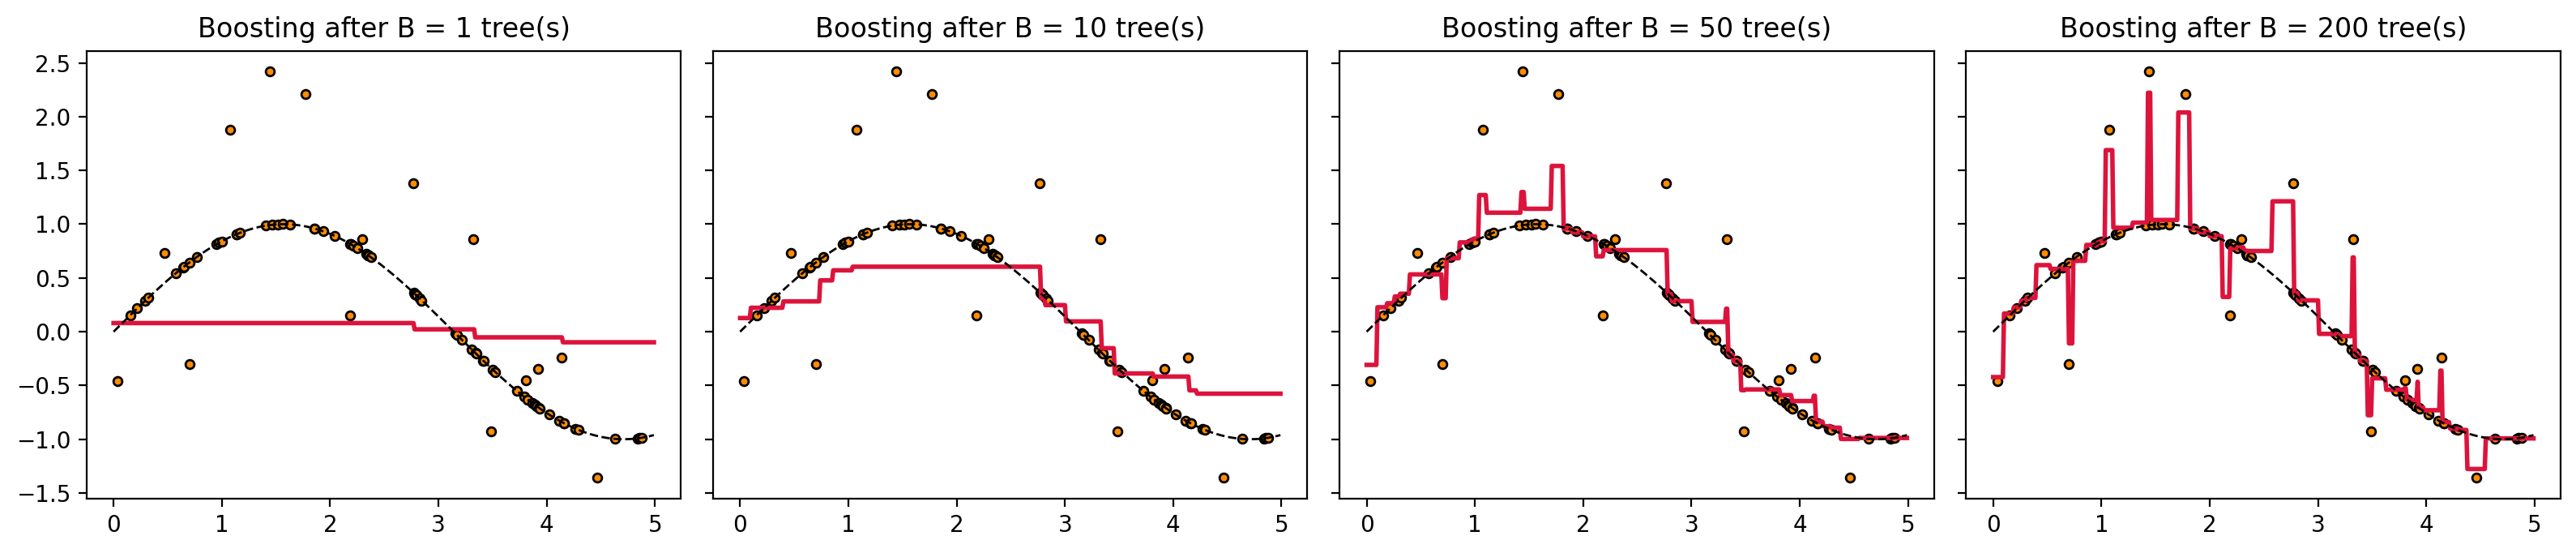

In [13]:
# Boosting "by hand" on the sine data, following the recipe above
lam, d = 0.1, 2
f_train = np.zeros(len(y_sin))          # current fitted values on the training points
f_grid = np.zeros(len(X_grid))          # current prediction curve (for plotting)
snapshots = {}

for b in range(1, 201):
    resid = y_sin - f_train                                        # what is still unexplained
    small_tree = DecisionTreeRegressor(max_depth=d).fit(X_sin, resid)
    f_train += lam * small_tree.predict(X_sin)                     # take a small step
    f_grid += lam * small_tree.predict(X_grid)
    if b in (1, 10, 50, 200):
        snapshots[b] = f_grid.copy()

fig, ax = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)
for a, (b, curve) in zip(ax, snapshots.items()):
    a.scatter(X_sin, y_sin, s=15, c="darkorange", edgecolor="black")
    a.plot(X_grid, curve, color="crimson", lw=2)
    a.plot(X_grid, np.sin(X_grid), "k--", lw=1)
    a.set_title(f"Boosting after B = {b} tree(s)")
plt.tight_layout()
plt.show()

**How to read the plots.** After 1 tree the model is a tiny, shrunk step function (only $\lambda = 10\%$ of one depth-2 tree), so it underfits badly and has **high bias**. Each new tree removes part of the remaining error, and by $B = 50$ the curve roughly follows $\sin(x)$. Keep going: at $B = 200$ the model is chasing the individual outliers, which means it is **overfitting**. This is the key difference from bagging:

### In boosting, the number of trees $B$ is a tuning parameter

- **Random forest:** more trees only average away noise, so test error falls and then **flattens**. Set $B$ as large as you can afford.
- **Boosting:** each tree fits more of the training data. At first that removes bias, but eventually the trees fit **noise**, so test error falls and then **rises again**. $B$ must be chosen by cross-validation or **early stopping**.

The next cell shows this on the Friedman #1 data, where the true function is known:
$f_0(x) = 10\sin(\pi x_1 x_2) + 20(x_3 - 0.5)^2 + 10x_4 + 5x_5$, with 5 extra pure-noise variables.

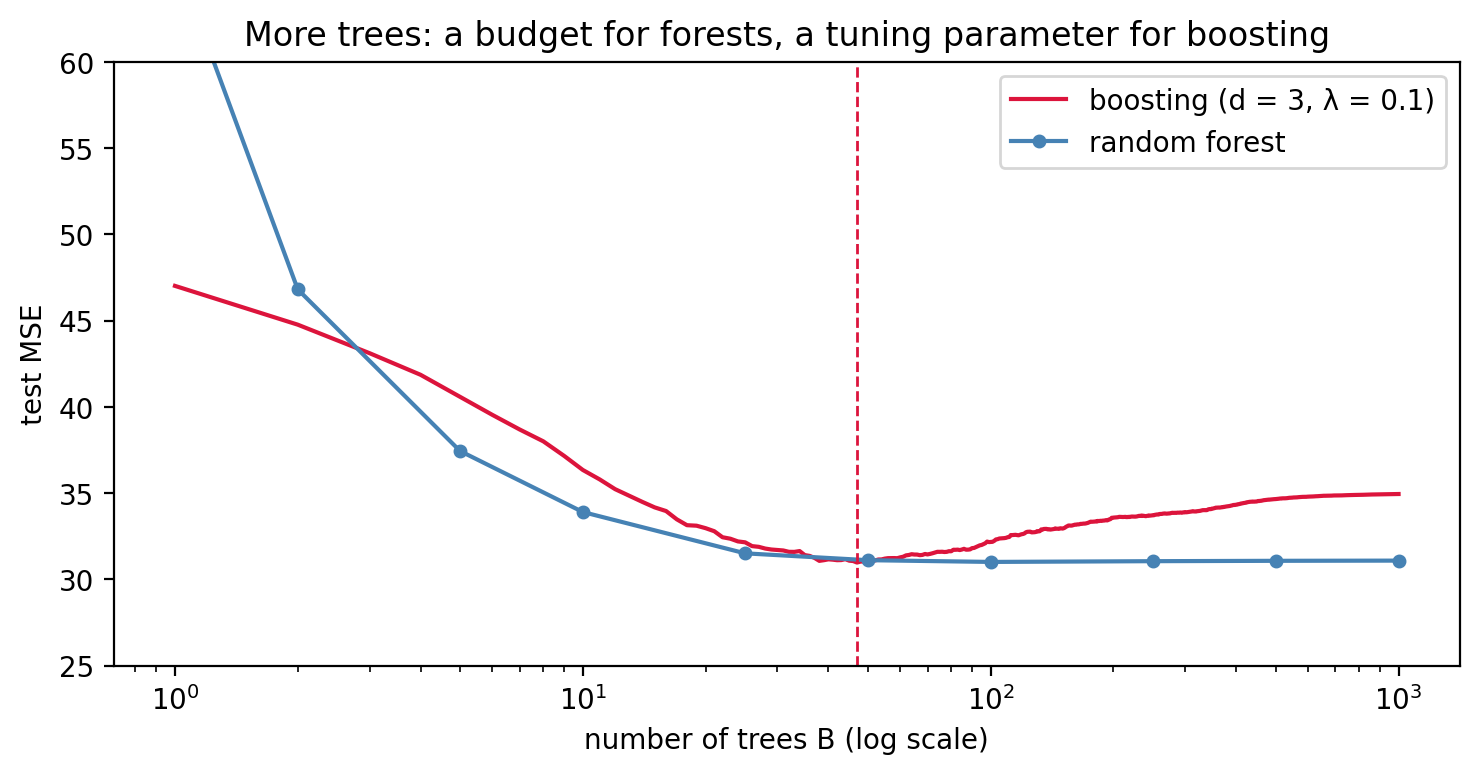

Boosting: best test MSE 30.97 at B = 47; at B = 1000 it is 34.95  -> too many trees hurts
Forest  : test MSE 66.09 with 1 tree, 31.08 with 1000 trees -> more trees never hurts

Early stopping chose B = 41 trees; test MSE = 33.37


In [14]:
from sklearn.datasets import make_friedman1
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error

X_f_tr, y_f_tr = make_friedman1(n_samples=300, n_features=10, noise=5.0, random_state=1)
X_f_te, y_f_te = make_friedman1(n_samples=2000, n_features=10, noise=5.0, random_state=2)

# Boosting: test error after each tree (staged_predict avoids refitting)
gb = GradientBoostingRegressor(n_estimators=1000, max_depth=3, learning_rate=0.1,
                               random_state=0).fit(X_f_tr, y_f_tr)
boost_curve = [mean_squared_error(y_f_te, p) for p in gb.staged_predict(X_f_te)]

# Random forest: refit with more and more trees
grid_B = [1, 2, 5, 10, 25, 50, 100, 250, 500, 1000]
rf_curve = [mean_squared_error(y_f_te, RandomForestRegressor(n_estimators=B, random_state=0, n_jobs=-1)
                               .fit(X_f_tr, y_f_tr).predict(X_f_te)) for B in grid_B]

plt.figure(figsize=(7.5, 4))
plt.plot(np.arange(1, 1001), boost_curve, color="crimson", label="boosting (d = 3, λ = 0.1)")
plt.plot(grid_B, rf_curve, "o-", ms=4, color="steelblue", label="random forest")
plt.axvline(np.argmin(boost_curve) + 1, ls="--", lw=1, color="crimson")
plt.xscale("log"); plt.ylim(25, 60)
plt.xlabel("number of trees B (log scale)"); plt.ylabel("test MSE")
plt.title("More trees: a budget for forests, a tuning parameter for boosting")
plt.legend(); plt.tight_layout(); plt.show()

print(f"Boosting: best test MSE {min(boost_curve):.2f} at B = {np.argmin(boost_curve) + 1}; "
      f"at B = 1000 it is {boost_curve[-1]:.2f}  -> too many trees hurts")
print(f"Forest  : test MSE {rf_curve[0]:.2f} with 1 tree, {rf_curve[-1]:.2f} with 1000 trees -> more trees never hurts")

# Early stopping: set aside 20% of the training data and stop when it stops improving
gb_es = GradientBoostingRegressor(n_estimators=5000, max_depth=3, learning_rate=0.1,
                                  validation_fraction=0.2, n_iter_no_change=20,
                                  random_state=0).fit(X_f_tr, y_f_tr)
print(f"\nEarly stopping chose B = {gb_es.n_estimators_} trees; "
      f"test MSE = {mean_squared_error(y_f_te, gb_es.predict(X_f_te)):.2f}")

### Tree depth $d$ = which interactions the model can learn

A **stump** ($d = 1$) splits on a single variable, so a sum of stumps is a sum of separate functions of each variable:

$$\hat f(x) = g_1(x_1) + g_2(x_2) + \dots + g_p(x_p).$$

This is an **additive model**, the nonparametric version of **OLS without interaction terms**. It can bend each variable's effect freely, but it can **never** capture an interaction such as $x_1 \times x_2$, no matter how many trees you add. A depth-2 tree can represent 2-way interactions, a depth-3 tree 3-way interactions, and so on.

| Boosting depth | Comparable regression | Can capture |
|---|---|---|
| $d = 1$ (stumps) | $y = g_1(x_1) + g_2(x_2) + \dots$ (no interactions) | nonlinear main effects |
| $d = 2$ | adds $x_j \times x_k$ terms | + 2-way interactions |
| $d = 3$ | adds $x_j \times x_k \times x_l$ terms | + 3-way interactions |

So **choosing $d$ is really choosing a modelling assumption**. Let's test this on a pure interaction, $f_0(x) = 10\sin(\pi x_1 x_2)$, which has no additive part at all:

In [15]:
rng_i = np.random.default_rng(11)
X_int = rng_i.uniform(0, 1, (3800, 5))
y_int = 10 * np.sin(np.pi * X_int[:, 0] * X_int[:, 1]) + rng_i.normal(0, 0.5, 3800)
X_int_tr, y_int_tr, X_int_te, y_int_te = X_int[:800], y_int[:800], X_int[800:], y_int[800:]

print("True f(x) = 10 sin(pi * x1 * x2): a pure 2-way interaction\n")
for depth in [1, 2, 3]:
    g = GradientBoostingRegressor(n_estimators=600, max_depth=depth, learning_rate=0.05,
                                  random_state=0).fit(X_int_tr, y_int_tr)
    note = "   <- stumps = additive model, cannot represent x1*x2" if depth == 1 else ""
    print(f"  max_depth = {depth}:  test MSE = {mean_squared_error(y_int_te, g.predict(X_int_te)):.3f}{note}")

True f(x) = 10 sin(pi * x1 * x2): a pure 2-way interaction

  max_depth = 1:  test MSE = 2.141   <- stumps = additive model, cannot represent x1*x2
  max_depth = 2:  test MSE = 0.554
  max_depth = 3:  test MSE = 0.459


With stumps, the test error stays several times higher than with $d = 2$. Adding more trees cannot fix this, because an additive model cannot represent this function. Once $d \ge 2$, the model can capture the interaction.

---

## Putting It All Together

| | OLS / LASSO | Single tree | Bagging | Random Forest | Boosting |
|---|---|---|---|---|---|
| **Basic idea** | linear in researcher-chosen $x$ | OLS on data-chosen leaf dummies | average many deep trees on bootstrap samples | bagging + random subset of variables at each split | add many small trees in sequence, each fit to the residuals |
| **Trees are** | — | one, pruned | many, **deep** | many, **deep** | many, **shallow** ($d$ = 1 to 5) |
| **Built** | — | once | in **parallel** | in **parallel** | **sequentially** |
| **Mainly reduces** | — | — | **variance** | **variance** (lower floor) | **bias** |
| **More trees** | — | — | never hurts | never hurts | eventually **overfits** |
| **Key knobs** | $\lambda$ (LASSO) | depth / `ccp_alpha` | $B$ | $B$, `max_features` | $B$, $\lambda$, $d$ |
| **Functional form** | you specify it | found automatically | found automatically | found automatically | found automatically; $d$ caps interactions |
| **Interpretability** | high (coefficients) | high (draw the tree) | low (variable importance) | low (variable importance) | low (variable importance) |
| **Out-of-the-box error estimate** | — | — | OOB | OOB | early-stopping validation set |
| **scikit-learn** | `LinearRegression`, `LassoCV` | `DecisionTreeRegressor` | `BaggingRegressor` | `RandomForestRegressor` | `GradientBoostingRegressor`, `HistGradientBoostingRegressor` |

**Flexibility is not free.** Tree ensembles win when the true relationship is **nonlinear or full of interactions**. When the true relationship is close to linear, OLS/LASSO get it with a few coefficients, while trees have to approximate a straight line with a staircase of splits. In the course lab on **CPS wages**, OLS and LASSO did as well as or *better than* every tree method, because log wages are nearly additive in education, experience and region/occupation effects.

The horse race below runs the same five methods on two simulated datasets, one **linear** and one **nonlinear**.

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def horse_race(X_tr, y_tr, X_te, y_te):
    models = {
        "OLS": LinearRegression(),
        "Single tree (depth 5)": DecisionTreeRegressor(max_depth=5, random_state=0),
        "Bagging (B=300)": RandomForestRegressor(n_estimators=300, max_features=1.0, random_state=0, n_jobs=-1),
        "Random forest (q=p/3, B=300)": RandomForestRegressor(n_estimators=300, max_features=1/3, random_state=0, n_jobs=-1),
        "Boosting (d=3, λ=0.05, early stop)": GradientBoostingRegressor(
            n_estimators=3000, max_depth=3, learning_rate=0.05,
            validation_fraction=0.2, n_iter_no_change=30, random_state=0),
    }
    return {name: r2_score(y_te, m.fit(X_tr, y_tr).predict(X_te)) for name, m in models.items()}

# World 1: linear, y = X beta + noise
rng_h = np.random.default_rng(0)
beta = rng_h.normal(0, 1, 10)
X_lin = rng_h.normal(0, 1, (2500, 10))
y_lin = X_lin @ beta + rng_h.normal(0, 1.5, 2500)
lin = horse_race(X_lin[:500], y_lin[:500], X_lin[500:], y_lin[500:])

# World 2: nonlinear with an interaction (Friedman #1), same sample size
X_nl_tr, y_nl_tr = make_friedman1(n_samples=500, n_features=10, noise=1.0, random_state=3)
X_nl_te, y_nl_te = make_friedman1(n_samples=2000, n_features=10, noise=1.0, random_state=4)
nonlin = horse_race(X_nl_tr, y_nl_tr, X_nl_te, y_nl_te)

pd.DataFrame({"Linear world: test R²": lin, "Nonlinear world: test R²": nonlin}).round(3)

,Linear world: test R²,Nonlinear world: test R²
OLS,0.712,0.724
Single tree (depth 5),0.261,0.649
Bagging (B=300),0.575,0.818
"Random forest (q=p/3, B=300)",0.563,0.790
"Boosting (d=3, λ=0.05, early stop)",0.625,0.880


**How to read the table.**

- **Linear world:** OLS is essentially unbeatable, because it is the correctly specified model. The tree methods lose accuracy trying to build a straight line out of steps. Boosting comes closest, since adding many small trees can approximate a smooth trend.
- **Nonlinear world:** OLS cannot capture $\sin(\pi x_1 x_2)$ or $(x_3 - 0.5)^2$. All three ensembles beat it, and boosting is the strongest here.
- In both worlds, **bagging and random forests clearly beat the single tree**. That gap is the variance reduction from averaging.

### Opening the black box: which variables matter?

We lose the single tree picture, but ensembles report **variable importance**: how much each variable reduced the prediction error, summed over all splits and trees. In the Friedman data, only $x_1$ to $x_5$ enter the true function. Variables $x_6$ to $x_{10}$ are pure noise.

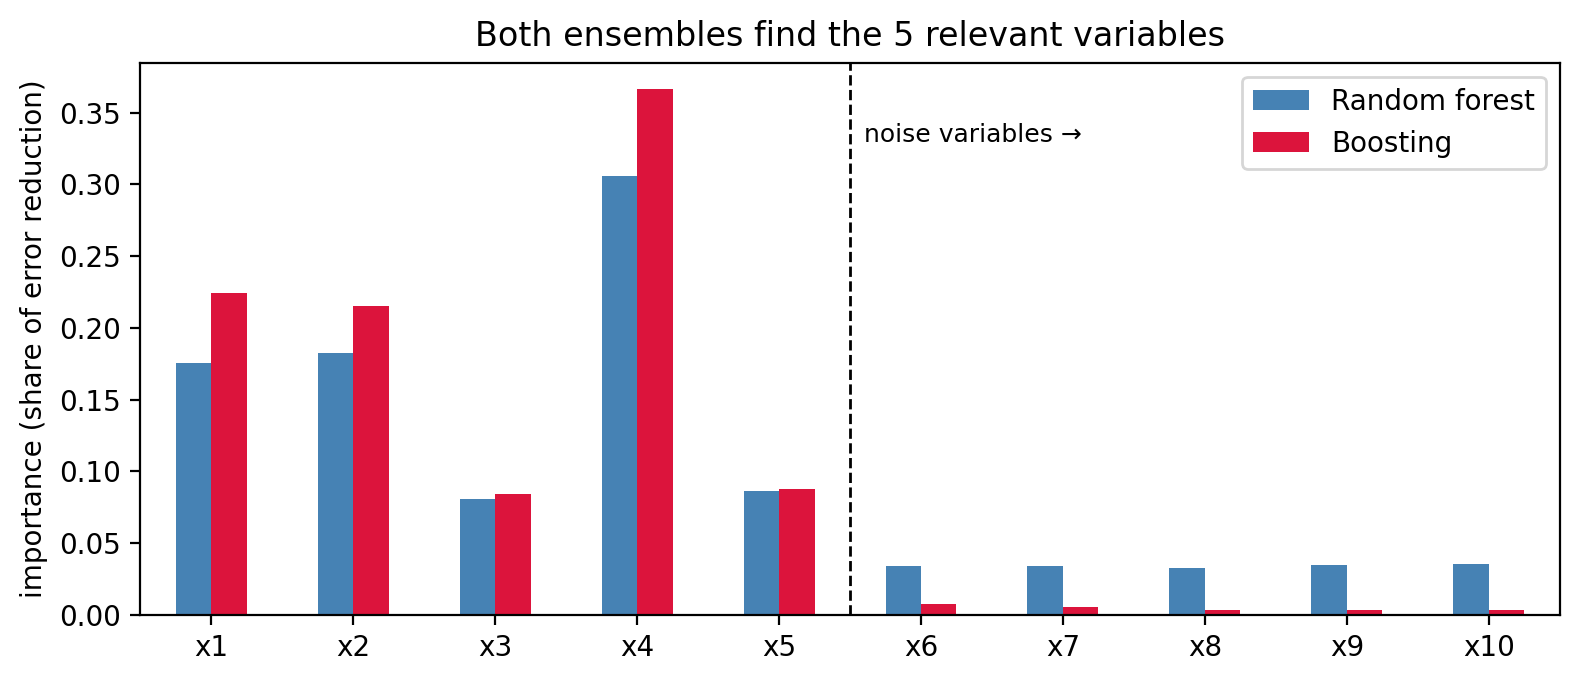

In [17]:
rf_imp = RandomForestRegressor(n_estimators=300, max_features=1/3, random_state=0, n_jobs=-1).fit(X_nl_tr, y_nl_tr)
gb_imp = GradientBoostingRegressor(n_estimators=500, max_depth=3, learning_rate=0.05, random_state=0).fit(X_nl_tr, y_nl_tr)

names = [f"x{j}" for j in range(1, 11)]
imp = pd.DataFrame({"Random forest": rf_imp.feature_importances_,
                    "Boosting": gb_imp.feature_importances_}, index=names)
imp.plot.bar(figsize=(8, 3.5), rot=0, color=["steelblue", "crimson"])
plt.axvline(4.5, color="k", ls="--", lw=1)
plt.text(4.6, imp.values.max() * 0.9, "noise variables →", fontsize=9)
plt.ylabel("importance (share of error reduction)")
plt.title("Both ensembles find the 5 relevant variables")
plt.tight_layout(); plt.show()

⚠ **Importance ≠ causal effect.** A high importance means "useful for **prediction**". It says nothing about the sign or size of a causal effect, and correlated variables share (or steal) importance from each other. Treat it like a predictive $R^2$ contribution, not like a regression coefficient with a standard error.

### Example applications

| Application | Outcome $y$ | Why an ensemble? | Good first choice |
|---|---|---|---|
| House prices (hedonic pricing) | sale price | location × size × age interactions, thresholds (e.g. school zones) | Random forest / boosting |
| Credit default / loan approval | default (0/1) | many borrower characteristics, nonlinear risk; the industry standard | Boosting (XGBoost / LightGBM) |
| Wage prediction (CPS) | log wage | the CEF is close to additive, so trees add little | OLS / LASSO, with a forest as a check |
| Demand or sales forecasting | units sold | many store/product/calendar variables with interactions | Boosting |
| Nowcasting GDP or inflation | growth rate | many noisy indicators, small samples | Random forest (robust, little tuning) |
| First-stage / nuisance models in causal inference (e.g. propensity scores, later with DML) | treatment or outcome | we only need good *predictions* of $E[D \mid X]$ or $E[Y \mid X]$, not interpretable coefficients | Random forest / boosting |

### Practical tips

1. **Always start with a linear benchmark** (OLS/LASSO). Report how much the ensemble improves on it out of sample. If the improvement is small, the linear model is easier to explain.
2. **Random forest = the safe default.** It works well with little tuning. Use many trees (a few hundred or more) and try a few values of `max_features`, checking the OOB score (`oob_score=True`).
3. **Boosting = often the most accurate, but needs tuning.** Fix a small `learning_rate` (0.05 to 0.1), try `max_depth` in {1, 2, 3, 5}, and **choose `n_estimators` by early stopping or CV**. Never report an untuned $B$.
4. For large datasets use `HistGradientBoostingRegressor/Classifier` (much faster, handles missing values), or XGBoost / LightGBM.
5. These are **prediction** tools. The leaves are chosen using $y$ and the fits are deliberately regularized, so the usual standard errors and $t$-tests do not apply. Causal questions need extra machinery (e.g. Double/Debiased ML, later in the course).

### Key takeaways

- A tree is OLS on data-chosen dummies: **flexible but high variance**.
- **Bagging** = bootstrap + average: reduces variance, keeps bias. $B$ is a budget, and OOB gives free validation.
- **Random forest** = bagging + a random subset of variables at each split: less correlated trees, so the average has **lower variance**.
- **Boosting** = small trees fit sequentially to residuals: reduces **bias**. $B$, $\lambda$ and $d$ are all tuning parameters, and $d$ sets the interaction order.
- Ensembles win when the truth is nonlinear with interactions. When the truth is close to linear, **OLS/LASSO are hard to beat**.